In [8]:
import pandas as pd
import numpy as np

# 读取 Excel 表格
file_path = 'new_pillar1724.xlsx'  # 替换为你的 Excel 文件路径

# 加载数据
df = pd.read_excel(file_path)

# 添加新列
df['CPt+1/CP'] = np.nan
df['CL/CP'] = np.nan
df['bart+1/CP'] = np.nan

# 计算新列
for n in range(len(df) - 1):  # n 不能是最后一行
    Dn = df.iloc[n, 3]  # 假设 D 列是第四列（索引3）
    Dn_plus_1 = df.iloc[n + 1, 3]  # D(n+1) 是 D 列的下一行
    En = df.iloc[n, 4]  # 假设 E 列是第五列（索引4）
    Jn = df.iloc[n, 9]  # 假设 J 列是第十列（索引9）

    # 计算 Kn
    if pd.notna(Dn) and pd.notna(Dn_plus_1) and Dn > 0 and Dn_plus_1 > 0:
        df.at[n, 'CPt+1/CP'] = np.log(Dn_plus_1 / Dn)

    # 计算 Ln
    if pd.notna(Dn) and pd.notna(En) and Dn > 0 and En > 0:
        df.at[n, 'CL/CP'] = np.log(En / Dn)

    # 计算 Mn
    if pd.notna(Dn) and pd.notna(Jn) and Dn > 0 and Jn > 0:
        df.at[n, 'bart+1/CP'] = np.log(Jn / Dn)

# 将结果保存到新的 Excel 文件
output_file_path = 'regression data1724_regime1.xlsx'  # 替换为你想保存的文件路径
df.to_excel(output_file_path, index=False)

In [9]:
import pandas as pd
import numpy as np

# 读取 Excel 表格
file_path = 'new_pillar1724.xlsx'  # 替换为你的 Excel 文件路径

# 加载数据
df = pd.read_excel(file_path)

# 添加新列
df['CPt+1/CP'] = np.nan
df['CL/CP'] = np.nan
df['NTt+1/CP'] = np.nan

# 计算新列
for n in range(len(df) - 1):  
    Dn = df.iloc[n, 3]  
    Dn_plus_1 = df.iloc[n + 1, 3]  
    En = df.iloc[n, 4]  
    In = df.iloc[n, 8]  

    # 计算 Kn
    if pd.notna(Dn) and pd.notna(Dn_plus_1) and Dn > 0 and Dn_plus_1 > 0:
        df.at[n, 'CPt+1/CP'] = np.log(Dn_plus_1 / Dn)

    # 计算 Ln
    if pd.notna(Dn) and pd.notna(En) and Dn > 0 and En > 0:
        df.at[n, 'CL/CP'] = np.log(En / Dn)

    # 计算 Mn
    if pd.notna(Dn) and pd.notna(In) and Dn > 0 and Jn > 0:
        df.at[n, 'NTt+1/CP'] = np.log(In / Dn)

# 将结果保存到新的 Excel 文件
output_file_path = 'regression data1724_regime2.xlsx'  # 替换为你想保存的文件路径
df.to_excel(output_file_path, index=False)

In [10]:
import pandas as pd
import numpy as np

# 读取 Excel 表格
file_path = 'new_pillar1724.xlsx'  # 替换为你的 Excel 文件路径

# 加载数据
df = pd.read_excel(file_path)

# 添加新列
df['CPt+1/CP'] = np.nan
df['CL/CP'] = np.nan
df['NTt+1/CP'] = np.nan
df['DT/CP'] = np.nan

# 计算新列
for n in range(len(df) - 1):  
    Dn = df.iloc[n, 3]  
    Dn_plus_1 = df.iloc[n + 1, 3]  
    En = df.iloc[n, 4]  
    In = df.iloc[n, 8]
    Hn = df.iloc[n, 7]

    
    if pd.notna(Dn) and pd.notna(Dn_plus_1) and Dn > 0 and Dn_plus_1 > 0:
        df.at[n, 'CPt+1/CP'] = np.log(Dn_plus_1 / Dn)

    
    if pd.notna(Dn) and pd.notna(En) and Dn > 0 and En > 0:
        df.at[n, 'CL/CP'] = np.log(En / Dn)

    
    if pd.notna(Dn) and pd.notna(In) and Dn > 0 and In > 0:
        df.at[n, 'NTt+1/CP'] = np.log(In / Dn)
    
    if pd.notna(Dn) and pd.notna(Hn) and Dn > 0 and Hn > 0:
        df.at[n, 'DT/CP'] = np.log(Hn / Dn)

# 将结果保存到新的 Excel 文件
output_file_path = 'regression data1724_regime3.xlsx'  # 替换为你想保存的文件路径
df.to_excel(output_file_path, index=False)

In [11]:
import pandas as pd
import statsmodels.api as sm

# 读取 Excel 文件
df = pd.read_excel('regression data1724_regime1.xlsx', sheet_name='Sheet1')

# 确保数据没有缺失值
df.dropna(inplace=True)

# 因变量和自变量
y = df.iloc[:, 10]  # 因变量在第11列
X = df.iloc[:, 11:13]  # 自变量在第12和第13列
X = sm.add_constant(X)

rolling_coefs = []
rolling_adj_r2 = []

# 滚动回归
for i in range(30, len(df)):
    y_window = y[i-30:i]
    X_window = X.iloc[i-30:i]

    model = sm.OLS(y_window, X_window).fit()
    

    # 确保只取自变量的系数
    rolling_coefs.append(model.params.values)  # 取所有系数
    rolling_adj_r2.append(model.rsquared_adj)  # 获取调整后的 R²

# 将结果转为 DataFrame
# 直接使用参数的数量来动态生成列名
coef_df = pd.DataFrame(rolling_coefs, columns=['Coef_Constant'] + [f'Coef_X{i+1}' for i in range(X.shape[1] - 1)])
adj_r2_df = pd.DataFrame(rolling_adj_r2, columns=['Adj_R2'])
results_df = pd.concat([df.iloc[29:].reset_index(drop=True), coef_df, adj_r2_df], axis=1)

# 导出结果到 Excel
results_df.to_excel('rolling_regression_results_regime1.xlsx', index=False)

In [12]:
import pandas as pd
import statsmodels.api as sm

# 读取 Excel 文件
df = pd.read_excel('regression data1724_regime2.xlsx', sheet_name='Sheet1')

# 确保数据没有缺失值
df.dropna(inplace=True)

# 因变量和自变量
y = df.iloc[:, 10]  # 因变量在第11列
X = df.iloc[:, 11:13]  # 自变量在第12和第13列

X = sm.add_constant(X)

rolling_coefs = []
rolling_adj_r2 = []

# 滚动回归
for i in range(30, len(df)):
    y_window = y[i-30:i]
    X_window = X.iloc[i-30:i]

    model = sm.OLS(y_window, X_window).fit()
    

    # 确保只取自变量的系数
    rolling_coefs.append(model.params.values)  # 取所有系数
    rolling_adj_r2.append(model.rsquared_adj)  # 获取调整后的 R²

# 将结果转为 DataFrame
# 直接使用参数的数量来动态生成列名
coef_df = pd.DataFrame(rolling_coefs, columns=['Coef_Constant'] + [f'Coef_X{i+1}' for i in range(X.shape[1] - 1)])
adj_r2_df = pd.DataFrame(rolling_adj_r2, columns=['Adj_R2'])
results_df = pd.concat([df.iloc[29:].reset_index(drop=True), coef_df, adj_r2_df], axis=1)

# 导出结果到 Excel
results_df.to_excel('rolling_regression_results_regime2.xlsx', index=False)

In [13]:
import pandas as pd
import statsmodels.api as sm

# 读取 Excel 文件
df = pd.read_excel('regression data1724_regime3.xlsx', sheet_name='Sheet1')

# 确保数据没有缺失值
df.dropna(inplace=True)

# 因变量和自变量
y = df.iloc[:, 10]  # 因变量在第11列
X = df.iloc[:, 11:14]  # 自变量在第12,13,14列

X = sm.add_constant(X)

rolling_coefs = []
rolling_adj_r2 = []

# 滚动回归
for i in range(30, len(df)):
    y_window = y[i-30:i]
    X_window = X.iloc[i-30:i]

    model = sm.OLS(y_window, X_window).fit()
    

    # 确保只取自变量的系数
    rolling_coefs.append(model.params.values)  # 取所有系数
    rolling_adj_r2.append(model.rsquared_adj)  # 获取调整后的 R²

# 将结果转为 DataFrame
# 直接使用参数的数量来动态生成列名
coef_df = pd.DataFrame(rolling_coefs, columns=['Coef_Constant'] + [f'Coef_X{i+1}' for i in range(X.shape[1] - 1)])
adj_r2_df = pd.DataFrame(rolling_adj_r2, columns=['Adj_R2'])
results_df = pd.concat([df.iloc[29:].reset_index(drop=True), coef_df, adj_r2_df], axis=1)

# 导出结果到 Excel
results_df.to_excel('rolling_regression_results_regime3.xlsx', index=False)

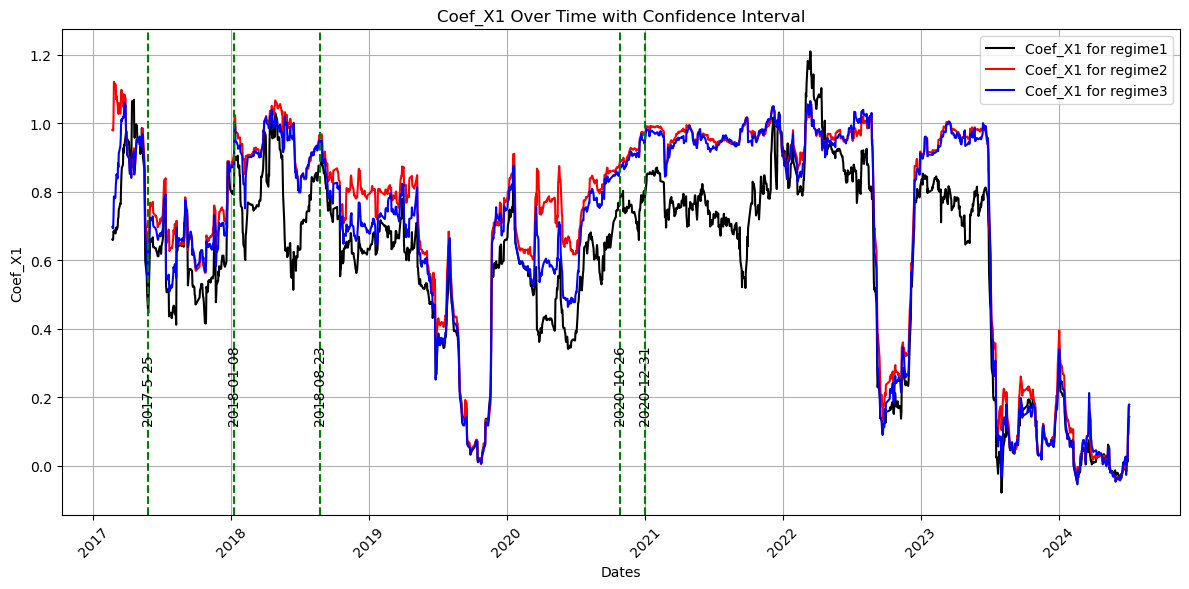

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df1 = pd.read_excel('rolling_regression_results_regime1.xlsx') 
df2 = pd.read_excel('rolling_regression_results_regime2.xlsx')
df3 = pd.read_excel('rolling_regression_results_regime3.xlsx')

# 绘制图表
plt.figure(figsize=(12, 6))

# 绘制 Coef_X1 和置信区间
plt.plot(df1['Date'], df1['Coef_X1'], label='Coef_X1 for regime1', color='black')


plt.plot(df2['Date'], df2['Coef_X1'], label='Coef_X1 for regime2', color='red')


plt.plot(df3['Date'], df3['Coef_X1'], label='Coef_X1 for regime3', color='blue')


# 设置标题和标签
plt.title('Coef_X1 Over Time with Confidence Interval')
plt.xlabel('Dates')
plt.ylabel('Coef_X1')
plt.xticks(rotation=45)  # 旋转日期标签以便更清楚地显示
plt.legend()

# 添加垂直线
highlight_date = '2017-5-25'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-01-08'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-08-23'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-10-26'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-12-31'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)


# 设置网格
plt.grid()
plt.savefig('coefX1_1724.png', bbox_inches='tight')

# 显示图形
plt.tight_layout()
plt.show()

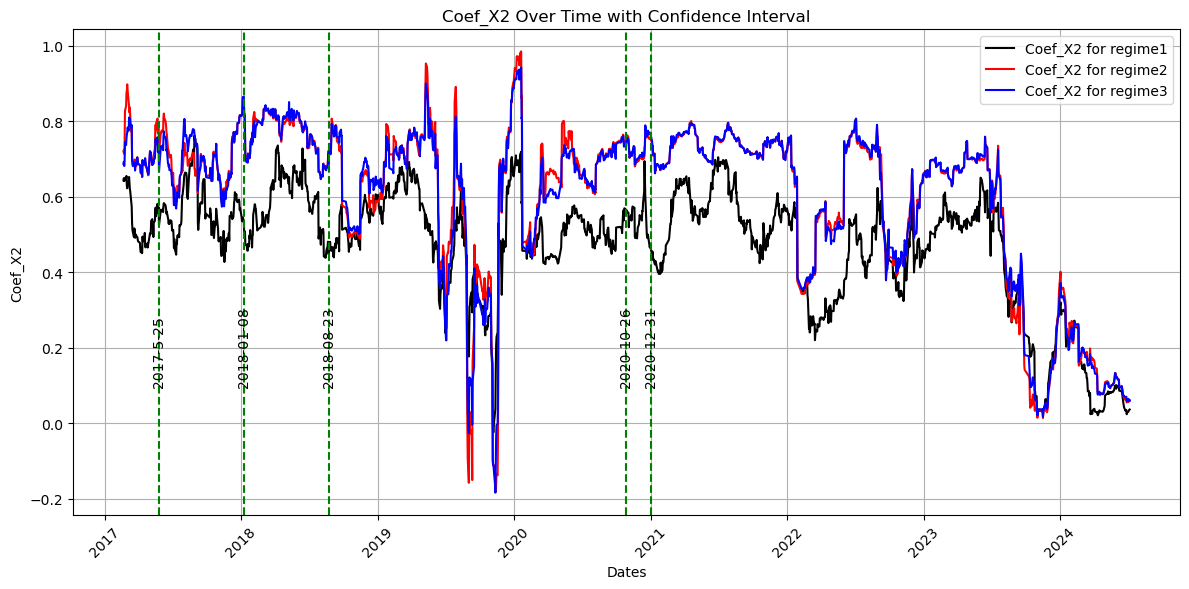

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df1 = pd.read_excel('rolling_regression_results_regime1.xlsx') 
df2 = pd.read_excel('rolling_regression_results_regime2.xlsx')
df3 = pd.read_excel('rolling_regression_results_regime3.xlsx')

# 绘制图表
plt.figure(figsize=(12, 6))

# 绘制 Coef_X1 和置信区间
plt.plot(df1['Date'], df1['Coef_X2'], label='Coef_X2 for regime1', color='black')

plt.plot(df2['Date'], df2['Coef_X2'], label='Coef_X2 for regime2', color='red')


plt.plot(df3['Date'], df3['Coef_X2'], label='Coef_X2 for regime3', color='blue')


# 设置标题和标签
plt.title('Coef_X2 Over Time with Confidence Interval')
plt.xlabel('Dates')
plt.ylabel('Coef_X2')
plt.xticks(rotation=45)  # 旋转日期标签以便更清楚地显示
plt.legend()

# 添加垂直线
highlight_date = '2017-5-25'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-01-08'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-08-23'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-10-26'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-12-31'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

# 设置网格
plt.grid()
plt.savefig('coefX2_1724.png', bbox_inches='tight')

# 显示图形
plt.tight_layout()
plt.show()

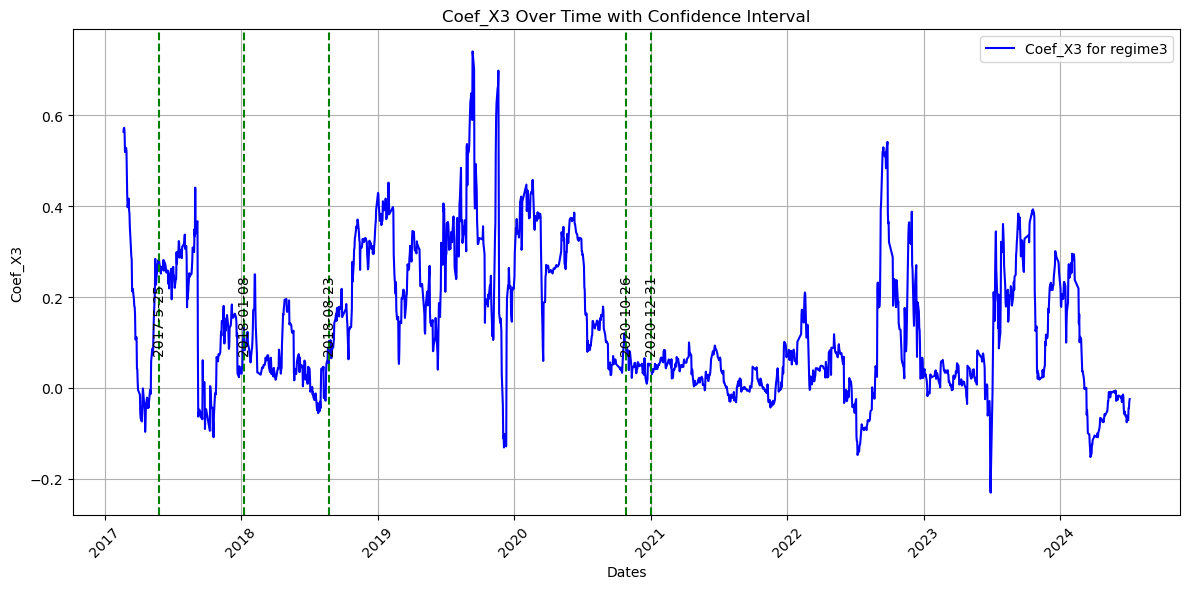

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df3 = pd.read_excel('rolling_regression_results_regime3.xlsx')

# 绘制图表
plt.figure(figsize=(12, 6))


plt.plot(df3['Date'], df3['Coef_X3'], label='Coef_X3 for regime3', color='blue')


# 设置标题和标签
plt.title('Coef_X3 Over Time with Confidence Interval')
plt.xlabel('Dates')
plt.ylabel('Coef_X3')
plt.xticks(rotation=45)  # 旋转日期标签以便更清楚地显示
plt.legend()

# 添加垂直线
highlight_date = '2017-5-25'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-01-08'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-08-23'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-10-26'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-12-31'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)


# 设置网格
plt.grid()
plt.savefig('coefX3_1724.png', bbox_inches='tight')

# 显示图形
plt.tight_layout()
plt.show()

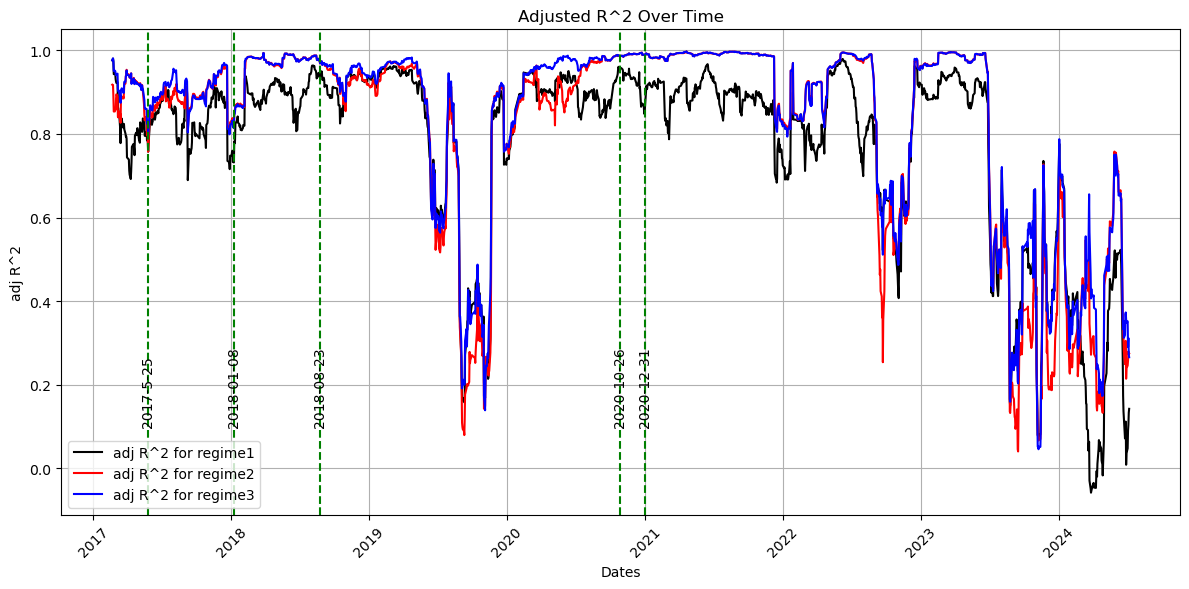

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df1 = pd.read_excel('rolling_regression_results_regime1.xlsx')  # 替换为您的文件名
df2 = pd.read_excel('rolling_regression_results_regime2.xlsx')
df3 = pd.read_excel('rolling_regression_results_regime3.xlsx')


# 绘制图表
plt.figure(figsize=(12, 6))

plt.plot(df1['Date'], df1['Adj_R2'], label='adj R^2 for regime1', color='black')
plt.plot(df2['Date'], df2['Adj_R2'], label='adj R^2 for regime2', color='red')
plt.plot(df3['Date'], df3['Adj_R2'], label='adj R^2 for regime3', color='blue')

# 设置标题和标签
plt.title('Adjusted R^2 Over Time')
plt.xlabel('Dates')
plt.ylabel('adj R^2')
plt.xticks(rotation=45)  # 旋转日期标签以便更清楚地显示
plt.legend()

# 添加垂直线
highlight_date = '2017-5-25'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-01-08'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2018-08-23'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-10-26'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)

highlight_date = '2020-12-31'
plt.axvline(pd.to_datetime(highlight_date), color='green', linestyle='--', label='Highlight Date')
plt.text(pd.to_datetime(highlight_date), plt.ylim()[1] * 0.1, highlight_date,
         horizontalalignment='center', color='black', rotation=90)
# 显示网格
plt.grid()
plt.savefig('adjusted_r2_over_time_1724.png', bbox_inches='tight') 

# 显示图形
plt.tight_layout()
plt.show()